# Entrenamiento de Modelos - Loan Prediction Dataset

Este notebook desarrolla el flujo completo de Machine Learning para el proyecto **Sistema Inteligente para la Prediccion de Aprobacion de Prestamos**.

Incluye lectura de datos, limpieza, tratamiento de valores nulos, tratamiento de outliers, One Hot Encoding, escalado, division train/test, entrenamiento, evaluacion, comparacion y guardado de artefactos con Joblib.

## 1. Importacion de librerias y configuracion inicial

In [1]:
# Librerias base para manipulacion de datos
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Herramientas de preprocesamiento y evaluacion
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Rutas principales del proyecto.
# Esta deteccion funciona si el notebook se ejecuta desde notebooks/ o desde la raiz del proyecto.
CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "dataset").exists() and (CURRENT_DIR / "models").exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "dataset").exists() and (CURRENT_DIR.parent / "models").exists():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "dataset"
MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"Directorio de dataset: {DATASET_DIR}")
print(f"Directorio de modelos: {MODELS_DIR}")

Directorio del proyecto: c:\Users\leocn\OneDrive\Escritorio\Final - Analitica de Datos\Proyecto_Analitica_Datos
Directorio de dataset: c:\Users\leocn\OneDrive\Escritorio\Final - Analitica de Datos\Proyecto_Analitica_Datos\dataset
Directorio de modelos: c:\Users\leocn\OneDrive\Escritorio\Final - Analitica de Datos\Proyecto_Analitica_Datos\models


## 2. Lectura del dataset

In [2]:
# Nombres comunes del Loan Prediction Dataset.
# Coloca el archivo CSV dentro de la carpeta dataset/ del proyecto.
candidate_files = [
    "loan_prediction.csv",
    "LoanPrediction.csv",
    "train.csv",
    "train_u6lujuX_CVtuZ9i.csv",
    "loan_data.csv",
]

dataset_path = None
for file_name in candidate_files:
    current_path = DATASET_DIR / file_name
    if current_path.exists():
        dataset_path = current_path
        break

if dataset_path is None:
    csv_files = list(DATASET_DIR.glob("*.csv"))
    if csv_files:
        dataset_path = csv_files[0]
    else:
        raise FileNotFoundError(
            "No se encontro un archivo CSV en dataset/. "
            "Agrega el Loan Prediction Dataset, por ejemplo: train_u6lujuX_CVtuZ9i.csv"
        )

# Lectura del dataset con pandas.
df = pd.read_csv(dataset_path)

print(f"Dataset cargado desde: {dataset_path}")
print(f"Dimensiones iniciales: {df.shape}")
df.head()

Dataset cargado desde: c:\Users\leocn\OneDrive\Escritorio\Final - Analitica de Datos\Proyecto_Analitica_Datos\dataset\train_u6lujuX_CVtuZ9i.csv.csv
Dimensiones iniciales: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Exploracion y limpieza inicial

In [3]:
# Copia de trabajo para conservar el dataframe original intacto.
data = df.copy()

# Normalizacion basica de nombres de columnas.
data.columns = data.columns.str.strip()

# Eliminacion de duplicados exactos.
duplicated_rows = data.duplicated().sum()
data = data.drop_duplicates().reset_index(drop=True)

print(f"Duplicados eliminados: {duplicated_rows}")
print(f"Dimensiones despues de limpieza inicial: {data.shape}")

# Resumen de tipos de datos y valores nulos.
summary = pd.DataFrame({
    "tipo_dato": data.dtypes,
    "nulos": data.isnull().sum(),
    "porcentaje_nulos": (data.isnull().mean() * 100).round(2),
})
summary

Duplicados eliminados: 0
Dimensiones despues de limpieza inicial: (614, 13)


,tipo_dato,nulos,porcentaje_nulos
Loan_ID,str,0,0.00
Gender,str,13,2.12
Married,str,3,0.49
Dependents,str,15,2.44
Education,str,0,0.00
Self_Employed,str,32,5.21
ApplicantIncome,int64,0,0.00
CoapplicantIncome,float64,0,0.00
LoanAmount,float64,22,3.58
Loan_Amount_Term,float64,14,2.28


## 4. Definicion de variable objetivo y variables predictoras

In [4]:
# El Loan Prediction Dataset suele usar Loan_Status como variable objetivo.
TARGET_COLUMN = "Loan_Status"

if TARGET_COLUMN not in data.columns:
    raise ValueError(
        f"No se encontro la columna objetivo '{TARGET_COLUMN}'. "
        f"Columnas disponibles: {list(data.columns)}"
    )

# Eliminacion de identificadores, porque no aportan informacion predictiva real.
id_columns = [col for col in data.columns if col.lower().endswith("id") or col.lower() == "id"]
print(f"Columnas identificadoras detectadas: {id_columns}")

# Separacion de variables predictoras y objetivo.
X = data.drop(columns=[TARGET_COLUMN] + id_columns, errors="ignore")
y_raw = data[TARGET_COLUMN]

# Codificacion de la variable objetivo a formato binario.
target_mapping = {
    "Y": 1,
    "N": 0,
    "Yes": 1,
    "No": 0,
    "Approved": 1,
    "Rejected": 0,
    1: 1,
    0: 0,
}
y = y_raw.map(target_mapping)

if y.isnull().any():
    raise ValueError(
        "La variable objetivo contiene categorias no reconocidas. "
        f"Valores encontrados: {sorted(y_raw.dropna().unique())}"
    )

y = y.astype(int)

# Identificacion automatica de columnas numericas y categoricas.
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Variables numericas: {numeric_features}")
print(f"Variables categoricas: {categorical_features}")
print("Distribucion de la variable objetivo:")
print(y.value_counts(normalize=True).rename("proporcion"))

Columnas identificadoras detectadas: ['Loan_ID']
Variables numericas: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Variables categoricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Distribucion de la variable objetivo:
Loan_Status
1    0.687296
0    0.312704
Name: proporcion, dtype: float64


## 5. Division Train/Test

In [5]:
# Se divide antes de ajustar transformadores para evitar fuga de informacion del test hacia el entrenamiento.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (491, 11)
X_test: (123, 11)
y_train: (491,)
y_test: (123,)


## 6. Tratamiento de valores nulos y outliers

In [6]:
def impute_missing_values(train_df, test_df, numeric_cols, categorical_cols):
    """Imputa nulos usando estadisticos calculados solo con train."""
    train_clean = train_df.copy()
    test_clean = test_df.copy()
    imputation_values = {"numeric": {}, "categorical": {}}

    # Numericas: mediana por robustez ante valores extremos.
    for col in numeric_cols:
        median_value = train_clean[col].median()
        imputation_values["numeric"][col] = median_value
        train_clean[col] = train_clean[col].fillna(median_value)
        test_clean[col] = test_clean[col].fillna(median_value)

    # Categoricas: moda; si no existe, se usa la categoria explicita 'Desconocido'.
    for col in categorical_cols:
        mode_series = train_clean[col].mode(dropna=True)
        mode_value = mode_series.iloc[0] if not mode_series.empty else "Desconocido"
        imputation_values["categorical"][col] = mode_value
        train_clean[col] = train_clean[col].fillna(mode_value)
        test_clean[col] = test_clean[col].fillna(mode_value)

    return train_clean, test_clean, imputation_values


def cap_outliers_iqr(train_df, test_df, numeric_cols):
    """Trata outliers numericos aplicando winsorizacion por IQR calculado en train."""
    train_capped = train_df.copy()
    test_capped = test_df.copy()
    outlier_limits = {}

    for col in numeric_cols:
        q1 = train_capped[col].quantile(0.25)
        q3 = train_capped[col].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outlier_limits[col] = {"lower": lower_limit, "upper": upper_limit}
        train_capped[col] = train_capped[col].clip(lower=lower_limit, upper=upper_limit)
        test_capped[col] = test_capped[col].clip(lower=lower_limit, upper=upper_limit)

    return train_capped, test_capped, outlier_limits


# Aplicacion del tratamiento de nulos.
X_train_clean, X_test_clean, imputation_values = impute_missing_values(
    X_train,
    X_test,
    numeric_features,
    categorical_features,
)

# Aplicacion del tratamiento de outliers.
X_train_clean, X_test_clean, outlier_limits = cap_outliers_iqr(
    X_train_clean,
    X_test_clean,
    numeric_features,
)

print("Nulos en train despues de imputacion:")
print(X_train_clean.isnull().sum())
print("\nLimites de outliers por variable numerica:")
outlier_limits

Nulos en train despues de imputacion:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Limites de outliers por variable numerica:


{'ApplicantIncome': {'lower': np.float64(-1472.5),
  'upper': np.float64(10203.5)},
 'CoapplicantIncome': {'lower': np.float64(-3361.5),
  'upper': np.float64(5602.5)},
 'LoanAmount': {'lower': np.float64(3.75), 'upper': np.float64(261.75)},
 'Loan_Amount_Term': {'lower': np.float64(360.0), 'upper': np.float64(360.0)},
 'Credit_History': {'lower': np.float64(1.0), 'upper': np.float64(1.0)}}

## 7. One Hot Encoding y escalado

In [7]:
# One Hot Encoding para variables categoricas.
# handle_unknown='ignore' evita errores si aparecen categorias nuevas en datos futuros.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

if categorical_features:
    X_train_encoded = encoder.fit_transform(X_train_clean[categorical_features])
    X_test_encoded = encoder.transform(X_test_clean[categorical_features])
    encoded_feature_names = encoder.get_feature_names_out(categorical_features).tolist()
else:
    X_train_encoded = np.empty((len(X_train_clean), 0))
    X_test_encoded = np.empty((len(X_test_clean), 0))
    encoded_feature_names = []

# Escalado de variables numericas con StandardScaler.
scaler = StandardScaler()

if numeric_features:
    X_train_scaled = scaler.fit_transform(X_train_clean[numeric_features])
    X_test_scaled = scaler.transform(X_test_clean[numeric_features])
else:
    X_train_scaled = np.empty((len(X_train_clean), 0))
    X_test_scaled = np.empty((len(X_test_clean), 0))

# Union final de variables numericas escaladas y variables categoricas codificadas.
feature_names = numeric_features + encoded_feature_names

X_train_processed = np.hstack([X_train_scaled, X_train_encoded])
X_test_processed = np.hstack([X_test_scaled, X_test_encoded])

print(f"Train procesado: {X_train_processed.shape}")
print(f"Test procesado: {X_test_processed.shape}")
print(f"Numero de columnas finales: {len(feature_names)}")

Train procesado: (491, 20)
Test procesado: (123, 20)
Numero de columnas finales: 20


## 8. Entrenamiento de modelos

In [8]:
# Diccionario de modelos solicitados para entrenamiento y comparacion.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
}

# Entrenamiento de todos los modelos.
trained_models = {}
for model_name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[model_name] = model
    print(f"Modelo entrenado: {model_name}")

Modelo entrenado: Logistic Regression
Modelo entrenado: Random Forest
Modelo entrenado: Support Vector Machine
Modelo entrenado: KNN
Modelo entrenado: Gaussian Naive Bayes


## 9. Evaluacion: Accuracy, Precision, Recall, F1, ROC, AUC y matriz de confusion

In [9]:
def get_positive_class_scores(model, X_data):
    """Obtiene scores probabilisticos o de decision para calcular ROC/AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return model.predict(X_data)


evaluation_results = []
confusion_matrices = {}
roc_curves = {}

for model_name, model in trained_models.items():
    # Prediccion de clase y score positivo.
    y_pred = model.predict(X_test_processed)
    y_score = get_positive_class_scores(model, X_test_processed)

    # Calculo de metricas principales.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_score)

    # Matriz de confusion y curva ROC.
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_score)

    evaluation_results.append({
        "Modelo": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc_score,
    })

    confusion_matrices[model_name] = cm
    roc_curves[model_name] = {"fpr": fpr, "tpr": tpr, "thresholds": thresholds}

# Tabla comparativa ordenada por F1 y AUC.
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by=["F1", "AUC"], ascending=False).reset_index(drop=True)
results_df

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.715447,0.711864,0.988235,0.827586,0.615480
1,Support Vector Machine,0.699187,0.696721,1.000000,0.821256,0.565944
2,KNN,0.691057,0.728155,0.882353,0.797872,0.511146
3,Gaussian Naive Bayes,0.658537,0.708738,0.858824,0.776596,0.578638
4,Random Forest,0.642276,0.695238,0.858824,0.768421,0.559288


## 10. Visualizacion comparativa de modelos

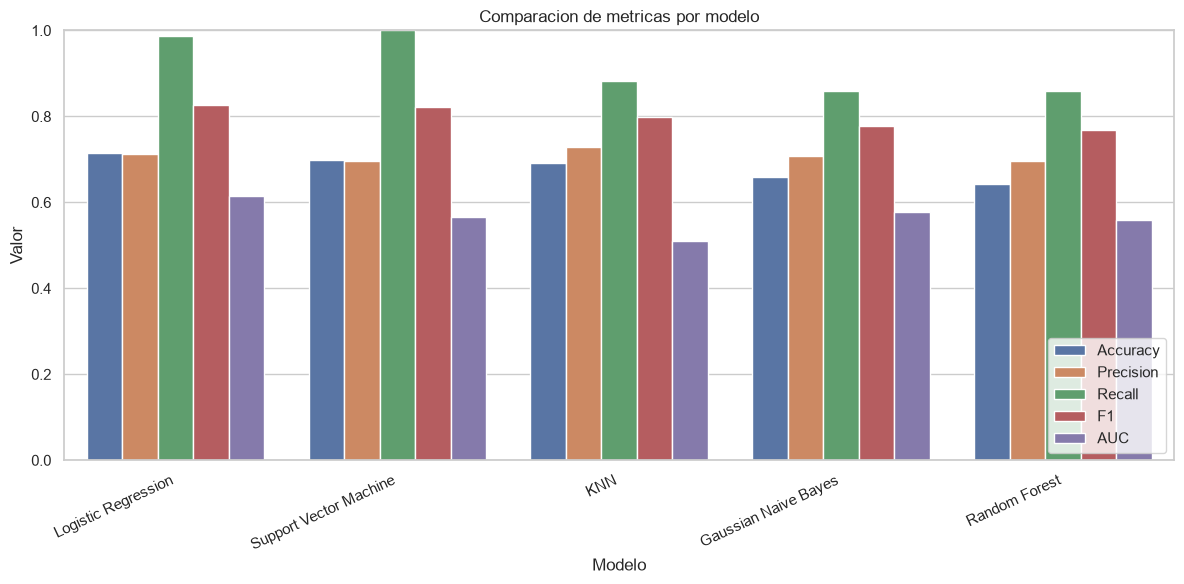

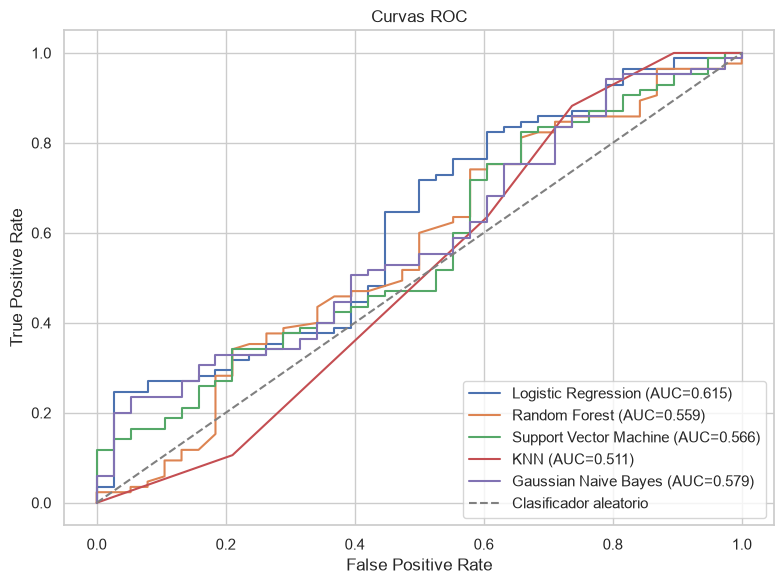

In [10]:
# Comparacion grafica de metricas principales.
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(id_vars="Modelo", value_vars=metrics_to_plot, var_name="Metrica", value_name="Valor")
sns.barplot(data=results_melted, x="Modelo", y="Valor", hue="Metrica")
plt.title("Comparacion de metricas por modelo")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Curvas ROC de todos los modelos.
plt.figure(figsize=(8, 6))
for model_name, curve_data in roc_curves.items():
    model_auc = results_df.loc[results_df["Modelo"] == model_name, "AUC"].values[0]
    plt.plot(curve_data["fpr"], curve_data["tpr"], label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.title("Curvas ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

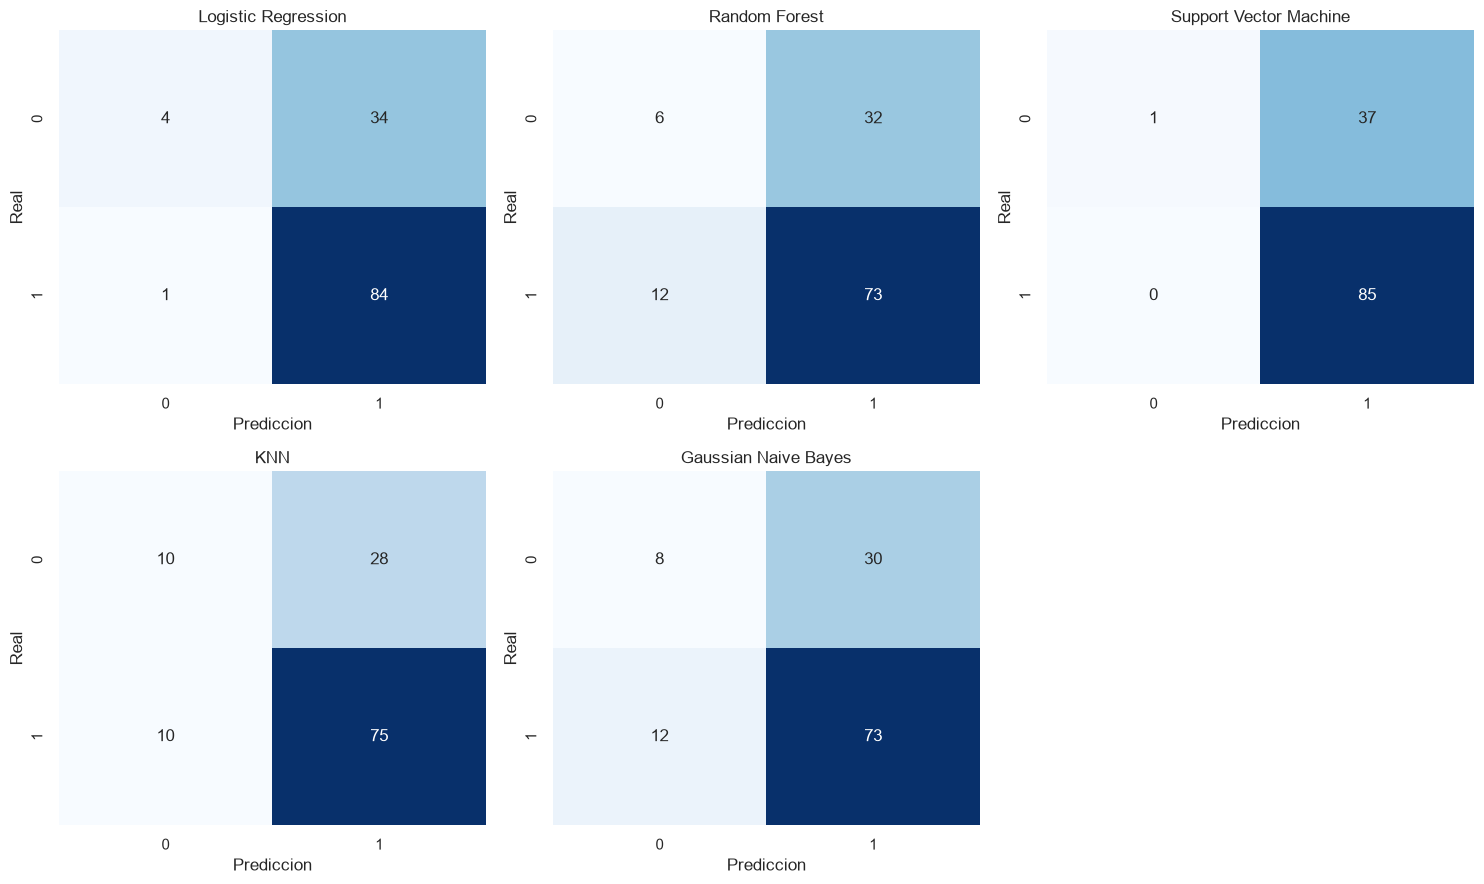

In [11]:
# Matrices de confusion para cada modelo.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for index, (model_name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[index])
    axes[index].set_title(model_name)
    axes[index].set_xlabel("Prediccion")
    axes[index].set_ylabel("Real")

# Se oculta el ultimo eje porque solo hay cinco modelos.
for extra_index in range(len(confusion_matrices), len(axes)):
    axes[extra_index].axis("off")

plt.tight_layout()
plt.show()

## 11. Guardado de modelos y artefactos con Joblib

In [12]:
# Mapeo entre nombres internos y archivos solicitados.
model_files = {
    "Logistic Regression": "logistic.pkl",
    "Random Forest": "randomforest.pkl",
    "Support Vector Machine": "svm.pkl",
    "KNN": "knn.pkl",
    "Gaussian Naive Bayes": "naivebayes.pkl",
}

# Guardado de modelos entrenados.
for model_name, file_name in model_files.items():
    joblib.dump(trained_models[model_name], MODELS_DIR / file_name)
    print(f"Guardado: {file_name}")

# Guardado de transformadores solicitados.
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(encoder, MODELS_DIR / "encoder.pkl")

# columns.pkl conserva la metadata necesaria para replicar el mismo preprocesamiento.
columns_metadata = {
    "target_column": TARGET_COLUMN,
    "id_columns": id_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "encoded_feature_names": encoded_feature_names,
    "feature_names": feature_names,
    "target_mapping": target_mapping,
    "imputation_values": imputation_values,
    "outlier_limits": outlier_limits,
    "best_model_by_f1": results_df.iloc[0]["Modelo"],
}
joblib.dump(columns_metadata, MODELS_DIR / "columns.pkl")

# metrics.json permite que Streamlit muestre metricas sin recalcularlas ni reentrenar modelos.
metrics_payload = {
    "best_model": results_df.iloc[0]["Modelo"],
    "ranking": results_df["Modelo"].tolist(),
    "metrics": results_df.to_dict(orient="records"),
    "confusion_matrices": {
        model_name: matrix.tolist()
        for model_name, matrix in confusion_matrices.items()
    },
    "roc_curves": {
        model_name: {
            "fpr": values["fpr"].tolist(),
            "tpr": values["tpr"].tolist(),
            "thresholds": values["thresholds"].tolist(),
        }
        for model_name, values in roc_curves.items()
    },
}

with open(MODELS_DIR / "metrics.json", "w", encoding="utf-8") as metrics_file:
    json.dump(metrics_payload, metrics_file, indent=4, ensure_ascii=False)

print("\nArtefactos guardados correctamente en la carpeta models/:")
for artifact in sorted(MODELS_DIR.glob("*.pkl")):
    print(f"- {artifact.name}")
print("- metrics.json")

Guardado: logistic.pkl
Guardado: randomforest.pkl
Guardado: svm.pkl
Guardado: knn.pkl
Guardado: naivebayes.pkl

Artefactos guardados correctamente en la carpeta models/:
- columns.pkl
- encoder.pkl
- knn.pkl
- logistic.pkl
- naivebayes.pkl
- randomforest.pkl
- scaler.pkl
- svm.pkl
- metrics.json


## 12. Conclusiones del entrenamiento

Al ejecutar todas las celdas, la tabla `results_df` permite comparar los cinco modelos entrenados segun Accuracy, Precision, Recall, F1 y AUC.

Los artefactos `.pkl` quedan guardados en la carpeta `models/` para ser integrados posteriormente en la aplicacion Streamlit.